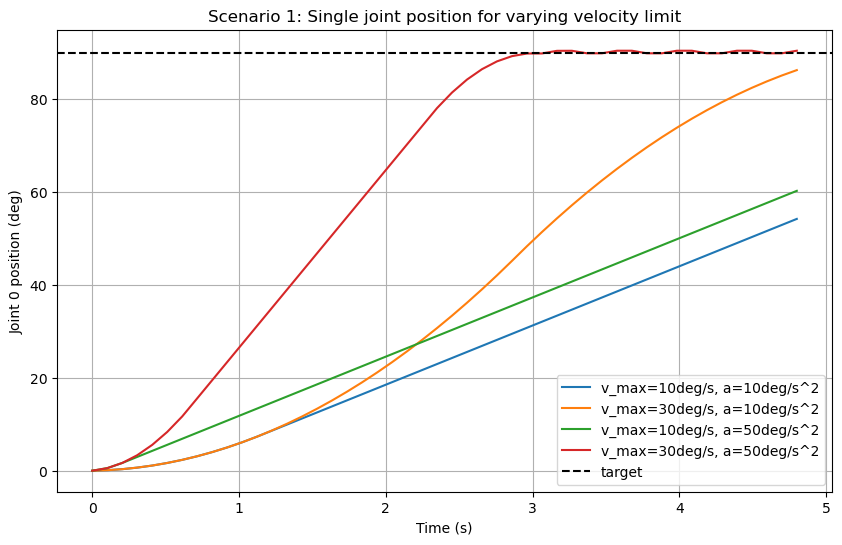

In [10]:
import sys, os
root = os.path.abspath(os.path.join(os.path.dirname(__file__) if '__file__' in dir() else os.getcwd(), '..', '..'))
sys.path.insert(0, root)

import numpy as np
import matplotlib.pyplot as plt
from models.model import MotionModel
from calibration.utils import load_parameters
model = MotionModel()

# Starting position
q0 = [0.0]
q_target = [1.57]

# Different velocites limits and accelerations to test the model
acceleration = [10,50]
max_vels = [10, 30]

parameters = load_parameters(os.path.join(root, "models/parameters.json"))

# Scaling factors
alpha_v = [parameters["vel_scale"][0]]
alpha_a = [parameters["acc_scale"][0]]

# Simulation parameters
dt=0.1
t_end=4.7


plt.figure(figsize=(10,6))
for a in acceleration:
    for v in max_vels:
        t, ql, qdl, qddl = model.simulate_joint_motion(q0, q_target, v, a, dt, t_end, alpha_v, alpha_a)
        plt.plot(t, np.rad2deg(ql[:,0]), label=f'v_max={v}deg/s, a={a}deg/s^2')
plt.axhline(np.rad2deg(q_target[0]), color='k', linestyle='--', label='target')
plt.xlabel('Time (s)'); plt.ylabel('Joint 0 position (deg)')
plt.title('Scenario 1: Single joint position for varying velocity limit')
plt.legend(); plt.grid(True); plt.show()
